# Handling Imbalanced & Messy Real-World Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

%matplotlib inline

## Load and Clean the Data

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df, drop_first=True)

### Check Class Balance and Visualize It

In [3]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


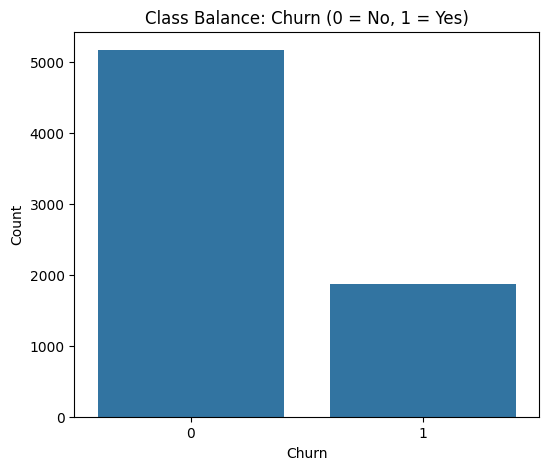

In [4]:
plt.figure(figsize=(6,5))
sns.countplot(x='Churn', data=df)
plt.title('Class Balance: Churn (0 = No, 1 = Yes)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

## Class Balance Check
The target variable is imbalanced: approximately 73% of customers did not
churn, while only 27% did. This means a naive model predicting "No churn"
for every customer would still score ~73% accuracy while being completely
useless at catching actual churners — exactly the kind of trap this task
is meant to teach us to avoid.

### Split Data and Train a Baseline Model (Before Fixing Imbalance)

In [5]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print("BASELINE (imbalanced) Results")
print(classification_report(y_test, y_pred_baseline))

BASELINE (imbalanced) Results
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Apply SMOTE to Balance the Training Data

In [6]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


### Retrain the Model on Balanced Data

In [7]:
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

print("SMOTE-Balanced Results")
print(classification_report(y_test, y_pred_smote))

SMOTE-Balanced Results
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1035
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409



C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
weighted_model = LogisticRegression(max_iter=1000, class_weight='balanced')
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

print("Class-Weighted Results")
print(classification_report(y_test, y_pred_weighted))

Class-Weighted Results
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Build Before/After Comparison Table

In [9]:
comparison = pd.DataFrame({
    'Approach': ['Baseline (Imbalanced)', 'SMOTE', 'Class Weighting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_weighted)
    ],
    'Precision (Churn)': [
        classification_report(y_test, y_pred_baseline, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_smote, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_weighted, output_dict=True)['1']['precision']
    ],
    'Recall (Churn)': [
        classification_report(y_test, y_pred_baseline, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_smote, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_weighted, output_dict=True)['1']['recall']
    ],
    'F1-score (Churn)': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_weighted)
    ]
})
comparison

,Approach,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Baseline (Imbalanced),0.804116,0.655063,0.553476,0.600000
1,SMOTE,0.759404,0.539863,0.633690,0.583026
2,Class Weighting,0.738112,0.504274,0.788770,0.615224


## Why Accuracy Can Be Misleading
About 73% of customers do not leave the company.
A model could get 73% accuracy just by predicting "No Churn" for everyone.
But this model would fail to find the customers who are actually leaving.
Precision, Recall, and F1-score give a better idea of how well the model finds customers who may churn.
These metrics are more useful because churned customers are the most important group for the business to identify.